<a href="https://colab.research.google.com/github/Vitoria-Emanuele/otimizacao-wsn-algoritmo-genetico/blob/main/avaliacao.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Otimização de Cobertura em Redes de Sensores Sem Fio utilizando Algoritmo Genético.


### Júlia Gabriele Mendes Barbosa e Vitória Emanuele de Sousa Silva


## I. Definição do Problema:


$$\min_{z} f(z) = \sum_{i \in S} (AE_i + PC_i + EC) \times y_i + \sum_{j \in M} \sum_{k \in D} (NC_{jk} + OPCE_{jk}) \times h_k$$

**Sujeito a (S.a.):**


$$g_1(z) = x_{ij} - y_i \le 0, \quad \forall i \in S, \forall ij \in A^d$$

$$g_2(z) = 1 - \sum_{i} (x_{ij} + h_j) \le 0, \quad \forall j \in D$$

**Restrições de escopo:**


$$y_i \in \{0, 1\}, \quad h_k \in \{0, 1\}, \quad z_i \in \{\text{00}, \text{01}, \text{10}, \text{11}\}$$



#### Onde:
 
- $z$: É a decisão. É uma lista (vetor) onde cada posição representa um sensor e armazena o seu modo de operação atual. 
- $M$: É o conjunto total de sensores disponíveis. 
- $D$: conjunto de pontos que precisam de monitoramento (o ponto de demanda geográfico específico tem uma coordenada na grade do mapa). 
- $S$: É o conjunto de todos os sensores (ativos ou inativos).
- $A^d$: Área de Demanda do sensor. Representa o "raio de alcance" ou a subárea geométrica que um sensor específico consegue monitorar quando está ligado.

- **Custo de Uso de Energia** ($UsageCost = \sum_{i \in S} (AE_i + PC_i + EC) \times y_i$): Mede o impacto energético de manter os sensores ativos. 

    - $y_i$ (Interruptor do Sensor $i$): É uma variável binária (0 ou 1). Sensor desligado $i$, $y_i = 0$ e $y_i = 1$ sensor ligado.


    - $AE_i$ (Energia de Ativação): O custo fixo de bateria só por o sensor estar ligado.


    - $PC_i$ (Custo de Caminho): O "esforço" que o sensor faz para mandar dados até a Estação Base. Se ele estiver muito longe, esse valor é alto (calculado via Dijkstra no código).


    - $EC$ (Consumo do Modo): O gasto extra dependendo do alcance escolhido (Modo A gasta 4, Modo B gasta 2, Modo C gasta 1).



- **Custo de Penalidade** ($PenaltyCost = \sum_{j \in M} \sum_{k \in D} (NC_{jk} + OPCE_{jk}) \times h_k$): Pune soluções que deixam áreas descobertas ou geram sobreposição excessiva.

    - $h_k$ (Indicador de Ponto Cego do ponto $k$): Vale **1** se a região $k$ ficou sem nenhum sensor olhando por ela, e **0** se a região estiver devidamente coberta.


    - $NC_{jk}$ (Custo de Não Cobertura): Uma multa pesada cobrada para cada ponto cego ($h_k = 1$). É isso que obriga o algoritmo a cobrir a área.


    - $OPCE_{jk}$ (Erro de Sobreposição): Uma multa caso haja muitos sensores cobrindo a mesmíssima região de forma desnecessária, desperdiçando recursos.



#### Restrições :

- $g_1(z) \le 0$ : Significa matematicamente que um ponto $j$ só pode ser marcado como "coberto pelo sensor $i$" ($x_{ij} = 1$) se esse sensor $i$ estiver ligado ($y_i = 1$). Um sensor desligado não cobre ninguém. Para todo sensor $i$ do seu conjunto total ($S$) , e para todo ponto $j$ que esteja dentro do raio de alcance dele ($A^d$), a relação tem que ser verdadeira. Se o sensor $i$ estiver desligado ($y_i = 0$), o ponto $j$ não pode ser considerado coberto ($x_{ij}$ é forçado a ser $0$, pois $0 - 0 \le 0$).


- $g_2(z) \le 0$ : Garante que o sistema é honesto. Ela força que cada ponto do mapa ou tenha pelo menos um sensor cobrindo ele ($x_{ij} \ge 1$) ou seja assumido e penalizado como um ponto cego ($h_j = 1$). Essa restrição avisa ao algoritmo que ficar cego tem um preço. Ou ele gasta energia ligando um sensor para cobrir o ponto $j$ ($x_{ij}=1$), ou ele assume o prejuízo e paga a multa por deixar o ponto descoberto ($h_j=1$).


## II. Definição dos elementos do Algoritmo Genético:
Com base na modelagem da rede de sensores dispostos em uma grade, o Algoritmo Genético (AG) é estruturado da seguinte maneira:

I. Cromossomo, genes e alelos **(Encode/Decode)**:

- **Cromossomo**: Uma solução inteira para a rede é representada por uma string de bits (cadeia binária).  O artigo menciona que para uma grade com $L^2$ nós, como cada nó precisa de 2 bits, o comprimento total é $2L^2$.
- **Genes**: Cada par de bits representa um nó sensor individual da grade.
- **Alelos**: Os valores que um gene pode assumir corresponde a 4 estados possíveis, codificados em 2 bits, que indicam o modo de operação do sensor:
    - 00: inativo (sensor desligado);
    - 01: modo A ativo (alcance longo, gasta 4x mais energia que o modo C);
    - 10: Modo B ativo (alcance médio, gasta 2x mais energia que o modo C);
    - 11: Modo C ativo (alcance curto).
- **Encode/Decode**: A função de encode lê a disposição espacial da grade de sensores atual e a transforma em uma string de bits sequencial. A função de decode realiza o inverso: mapeia a string binária do cromossomo de volta para a grade geográfica, associando a cada coordenada o seu respectivo modo de operação e raio de cobertura.

II. **Função de Aptidão (Fitness)**: Responsável por avaliar a qualidade de cada cromossomo populacional. Como nossa função objetivo $f(z)$ busca a minimização do custo total ($UsageCost + PenaltyCost$), a função de aptidão é matematicamente definida pelo inverso ou pelo oposto do custo para garantir que arranjos com menos pontos cegos e menor consumo de energia recebam as maiores notas de sobrevivência:

$$\text{Fitness}(c) = \frac{1}{f(z)}$$

III. **Seleção**: Utilizaremos o método da Roleta (Roulette-Wheel Selection). Nesse esquema, a probabilidade de um cromossomo ser escolhido para o acasalamento é diretamente proporcional à sua nota de aptidão:

$$P_i = \frac{F_i}{\sum_{j=1}^{n} F_j}$$

Onde $F_i$ é o fitness do cromossomo analisado e $n$ é o tamanho da população. Isso garante uma pressão seletiva que prioriza os arranjos mais eficientes de sensores.


IV. **Cruzamento (Crossover)**: Aplicaremos o cruzamento de Ponto Único (Single-Point Crossover). Dois cromossomos genitores ("pais") selecionados têm suas strings divididas em um ponto de corte aleatório. Os segmentos são recombinados e dão origem a dois novos indivíduos ("filhos") que herdam características combinadas de cobertura de ambos os pais.

V. **Mutação**: Consiste na alteração aleatória do alelo de um gene (par de bits) para outro modo de operação. Esse operador introduz variabilidade genética na população, permitindo que o algoritmo explore novos cenários de posicionamento que o cruzamento sozinho não alcançaria, evitando que o sistema fique preso em mínimos locais (soluções viciadas).

VI. **Condição de parada**: O critério estabelecido para encerrar a execução do algoritmo baseia-se em um limite fixo de 100 gerações (iterações do ciclo evolutivo), conforme os testes de convergência bem-sucedidos apresentados no artigo de referência.


## III. Dados do Problema:

Para simular o problema de Cobertura da Rede (Network Coverage) detalhado no artigo base, adotaremos um ambiente em formato de grade espacial (grid). Os parâmetros da simulação e as configurações do algoritmo genético seguirão os cenários propostos e validados pelos autores:

- **Ambiente Espacial:** Uma área monitorada de $100\text{m} \times 100\text{m}$.

- **Grade de Sensores:** Grade de Sensores: Para a modelagem da grade espacial de tamanho $L \times L$, adotaremos $L = 10$, totalizando exatamente $100$ nós sensores ($L^2 = 100$) distribuídos de forma geométrica e uniforme pelo campo.

- **Modos de Operação e Custo de Energia (EC):** Conforme a modelagem matemática do estudo, o consumo de energia é indexado de forma discreta de acordo com o raio de alcance de transmissão determinado pelo alelo:
    - Inativo (00): Custo de consumo = 0.
    - Modo A (01 - Longo alcance): Custo de consumo = 4 (consome 4 vezes mais que o modo C).
    - Modo B (10 - Médio alcance): Custo de consumo = 2 (consome 2 vezes mais que o modo C).
    - Modo C (11 - Curto alcance): Custo de consumo = 1 (parâmetro referencial básico).

- **Parâmetros do Algoritmo Genético:** A estrutura de hiperparâmetros para execução do ciclo evolutivo utilizará os seguintes valores fixados:
    - **Tamanho da população (`popsize`):** 100 indivíduos.
    - **Número de gerações (`ngen`):** 100 iterações (gerações máximas para critério de parada).
    - **Taxa de cruzamento (`pcross`):** 0.5 (50% de probabilidade de crossover de ponto único).
    - **Taxa de mutação (`pmut`):** 0.02 (2% de probabilidade de mutação por bit, derivado dos operadores operacionais do artigo).
    - **Comprimento do cromossomo:** $2L^2 = 200$ bits (onde cada um dos 100 nós sensores é representado por um gene de 2 bits consecutivos).



## IV. Implementação:

In [1]:
import random
import numpy as np
import matplotlib.pyplot as plt

### Parâmetros do problema

In [2]:
AREA_SIZE = 100
L = 10
NUM_SENSORS = L ** 2

# custos de energia (EC) dos alelos. Dicionario mapeando os bits para o respectivo custo de energia
ENERGY_COST = {
    '00': 0, # Desligado
    '01': 4, # modo A (longo alcance)
    '10': 2, # modo B (medio alcance)
    '11': 1  # modo C (curto alcance)
}

# raio de Cobertura (valores hipoteticos em metros para testar a aptidao)
COVERAGE_RADIUS = {
    '00': 0,
    '01': 30, # modo A cobre mais area
    '10': 20, # modo B cobre area media
    '11': 10  # modo C cobre area pequena
}

# parametros do algoritmo genetico
POP_SIZE = 100            # tamanho da populacao
NUM_GENERATIONS = 100     # condicao de parada (iteracoes)
CROSSOVER_RATE = 0.5      # taxa de cruzamento
MUTATION_RATE = 0.02       # taxa de mutacao
CHROMOSOME_LENGTH = NUM_SENSORS * 2 # comprimento: 200 bits

print(f"--- Inicialização: ---")
print(f"Total de Sensores: {NUM_SENSORS}")
print(f"Tamanho do Cromossomo: {CHROMOSOME_LENGTH} bits")
print(f"Tamanho da População: {POP_SIZE} indivíduos")


--- Inicialização: ---
Total de Sensores: 100
Tamanho do Cromossomo: 200 bits
Tamanho da População: 100 indivíduos


### Operadores e funções estruturais:

In [3]:

def create_individual(length):
    # gera um cromossomo aleatorio de '0's e '1's)
    return ''.join(random.choice(['0', '1']) for _ in range(length))

def create_population(pop_size, length):
    # inicializa a população com strings binarias
    return [create_individual(length) for _ in range(pop_size)]

def decode_chromosome(chromosome):
    # divide a string continua em pares de bits (genes)
    genes = [chromosome[i:i+2] for i in range(0, len(chromosome), 2)]
    return genes

def crossover(parent1, parent2, rate):
    # aplica cruzamento de ponto unico baseado na taxa informada
    if random.random() < rate:
        point = random.randint(1, len(parent1) - 1)

        child1 = parent1[:point] + parent2[point:]
        child2 = parent2[:point] + parent1[point:]
        return child1, child2
    return parent1, parent2

def mutate(chromosome, rate):
    # realiza a mutacao bit-by-bit (bit-flip)
    mutated = ""
    for bit in chromosome:
        if random.random() < rate:
            mutated += '1' if bit == '0' else '0'
        else:
            mutated += bit
    return mutated

In [4]:
def roulette_wheel_selection(population, fitness_scores):
    max_fitness = max(fitness_scores)

    inverted_scores = [max_fitness - score + 1 for score in fitness_scores]
    total_score = sum(inverted_scores)

    pick = random.uniform(0, total_score)
    current = 0
    for i, individual in enumerate(population):
        current += inverted_scores[i]
        if current >= pick:
            return individual
    return population[-1]

print("Operadores geneticos definidos com sucesso.")


Operadores geneticos definidos com sucesso.


Como a roleta sorteia fatias maiores para números maiores, e o objetivo do artigo é minimizar o uso de energia, nós implementamos uma lógica de inversão (max_fitness - score + 1) para garantir que os menores custos tenham a maior chance de serem sorteados.

In [5]:
def calculate_fitness(chromosome):
    # calcula a funcao objetivo: custo de energia + penalidade por ponto cego
    genes = decode_chromosome(chromosome)
    usage_cost = 0
    active_sensors = []

    # Mapeamento fisico e calculo do UsageCost
    for i, gene in enumerate(genes):
        usage_cost += ENERGY_COST[gene] 

        if gene != '00':
            x = (i % L) * (AREA_SIZE / L)
            y = (i // L) * (AREA_SIZE / L)
            active_sensors.append((x, y, COVERAGE_RADIUS[gene]))

    # Verificacao de cobertura e calculo do PenaltyCost
    penalty_cost = 0
    for i in range(NUM_SENSORS):
        target_x = (i % L) * (AREA_SIZE / L)
        target_y = (i // L) * (AREA_SIZE / L)
        is_covered = False

        for sx, sy, radius in active_sensors:
            distance = ((target_x - sx)**2 + (target_y - sy)**2)**0.5
            if distance <= radius:
                is_covered = True
                break

        # aplica penalidade severa (NC) para cada ponto cego, conforme modelagem matematica
        if not is_covered:
            penalty_cost += 50

    return usage_cost + penalty_cost


In [6]:
def plot_network_coverage(chromosome, title="Mapa de Cobertura da Rede"):
    # Renderiza a distribuição espacial dos sensores e seus raios de alcance
    genes = decode_chromosome(chromosome)
    fig, ax = plt.subplots(figsize=(7, 7))
    
    xs_a, ys_a, xs_b, ys_b, xs_c, ys_c, xs_off, ys_off = [], [], [], [], [], [], [], []
    
    for i, gene in enumerate(genes):
        x = (i % L) * (AREA_SIZE / (L - 1) if L > 1 else AREA_SIZE)
        y = (i // L) * (AREA_SIZE / (L - 1) if L > 1 else AREA_SIZE)
        
        if gene == '01':
            xs_a.append(x); ys_a.append(y)
            ax.add_patch(plt.Circle((x, y), COVERAGE_RADIUS[gene], color='blue', alpha=0.15))
        elif gene == '10':
            xs_b.append(x); ys_b.append(y)
            ax.add_patch(plt.Circle((x, y), COVERAGE_RADIUS[gene], color='orange', alpha=0.15))
        elif gene == '11':
            xs_c.append(x); ys_c.append(y)
            ax.add_patch(plt.Circle((x, y), COVERAGE_RADIUS[gene], color='green', alpha=0.15))
        else:
            xs_off.append(x); ys_off.append(y)

    if xs_a: ax.scatter(xs_a, ys_a, color='blue', marker='^', s=60, label='Modo A (Longo)')
    if xs_b: ax.scatter(xs_b, ys_b, color='orange', marker='s', s=60, label='Modo B (Médio)')
    if xs_c: ax.scatter(xs_c, ys_c, color='green', marker='o', s=60, label='Modo C (Curto)')
    if xs_off: ax.scatter(xs_off, ys_off, color='red', marker='x', s=40, alpha=0.4, label='Inativo (Desligado)')
    
    ax.set_xlim(-10, AREA_SIZE + 10)
    ax.set_ylim(-10, AREA_SIZE + 10)
    ax.set_title(title)
    ax.set_xlabel("Distância X (metros)")
    ax.set_ylabel("Distância Y (metros)")
    ax.legend(loc='upper right')
    ax.grid(True, linestyle='--', alpha=0.5)
    plt.show()

## V. Execução do algoritmo genético:

In [7]:
populacao_inicial = create_population(POP_SIZE, CHROMOSOME_LENGTH)

--- VISUALIZAÇÃO DA REDE ANTES DA OTIMIZAÇÃO (GERAÇÃO 0) ---
Custo Inicial Aleatório: 171


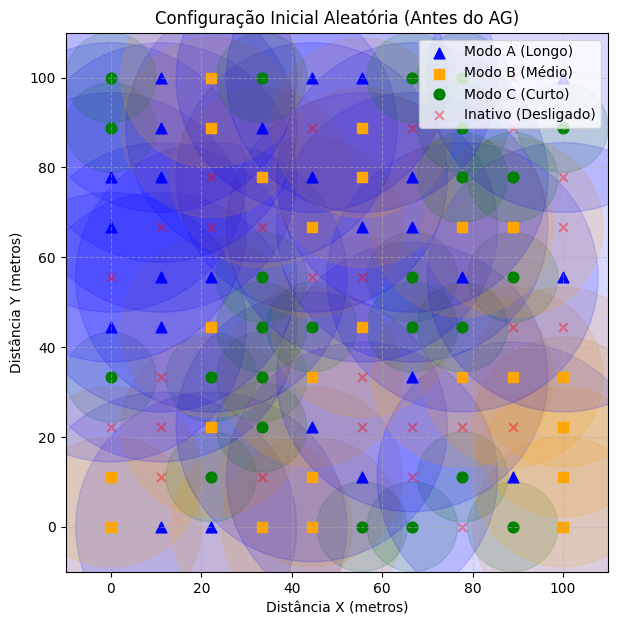

In [8]:
individuo_antes = populacao_inicial[0]

print("--- VISUALIZAÇÃO DA REDE ANTES DA OTIMIZAÇÃO (GERAÇÃO 0) ---")
print(f"Custo Inicial Aleatório: {calculate_fitness(individuo_antes)}")
plot_network_coverage(individuo_antes, title="Configuração Inicial Aleatória (Antes do AG)")


Geração 000 | Melhor Custo Atual: 133
Geração 010 | Melhor Custo Atual: 103
Geração 020 | Melhor Custo Atual: 91
Geração 030 | Melhor Custo Atual: 83
Geração 040 | Melhor Custo Atual: 79
Geração 050 | Melhor Custo Atual: 75
Geração 060 | Melhor Custo Atual: 71
Geração 070 | Melhor Custo Atual: 71
Geração 080 | Melhor Custo Atual: 71
Geração 090 | Melhor Custo Atual: 68

--- EVOLUÇÃO CONCLUÍDA ---
Custo Final Mínimo Otimizado: 68


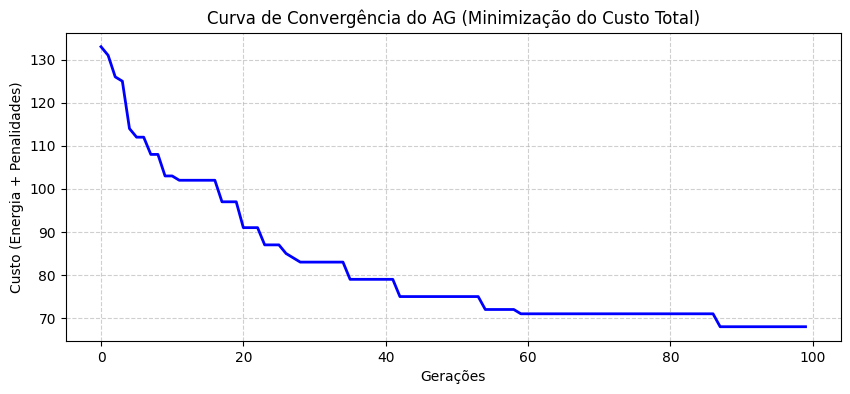

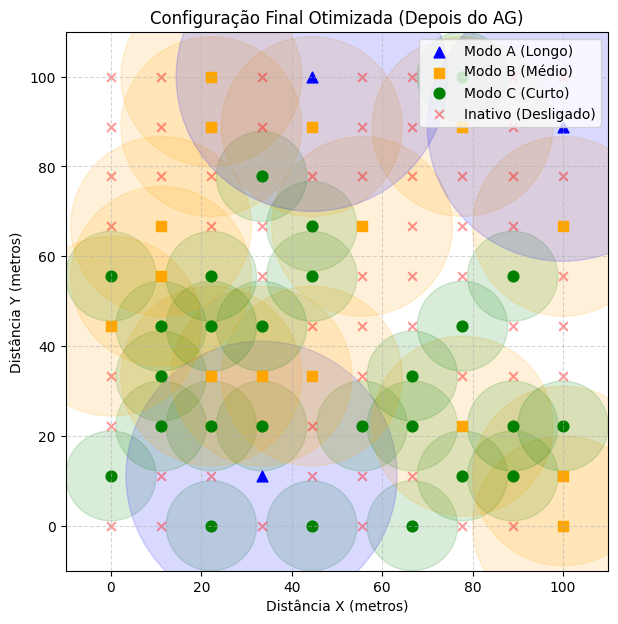

In [9]:
def run_genetic_algorithm_com_pop(pop_inicial):
    # Executa o AG a partir da população inicial gerada
    population = list(pop_inicial)
    best_fitness_history = []

    for generation in range(NUM_GENERATIONS):
        fitness_scores = [calculate_fitness(ind) for ind in population]
        best_generation_fitness = min(fitness_scores)
        best_fitness_history.append(best_generation_fitness)

        new_population = []
        
        # Elitismo: preserva a melhor solução atual
        best_index = fitness_scores.index(best_generation_fitness)
        new_population.append(population[best_index])

        while len(new_population) < POP_SIZE:
            parent1 = roulette_wheel_selection(population, fitness_scores)
            parent2 = roulette_wheel_selection(population, fitness_scores)

            child1, child2 = crossover(parent1, parent2, CROSSOVER_RATE)
            child1 = mutate(child1, MUTATION_RATE)
            child2 = mutate(child2, MUTATION_RATE)

            new_population.extend([child1, child2])

        population = new_population[:POP_SIZE]

        if generation % 10 == 0:
            print(f"Geração {generation:03d} | Melhor Custo Atual: {best_generation_fitness}")

    final_fitness_scores = [calculate_fitness(ind) for ind in population]
    best_overall_index = final_fitness_scores.index(min(final_fitness_scores))
    return population[best_overall_index], best_fitness_history

# Roda o AG passando a nossa população controlada
best_chromosome, history = run_genetic_algorithm_com_pop(populacao_inicial)

print(f"\n--- EVOLUÇÃO CONCLUÍDA ---")
print(f"Custo Final Mínimo Otimizado: {calculate_fitness(best_chromosome)}")


plt.figure(figsize=(10, 4))
plt.plot(history, color='blue', linewidth=2)
plt.title("Curva de Convergência do AG (Minimização do Custo Total)")
plt.xlabel("Gerações")
plt.ylabel("Custo (Energia + Penalidades)")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

plot_network_coverage(best_chromosome, title="Configuração Final Otimizada (Depois do AG)")

# Analise de Topologia (Antes x Depois da Otimização)

In [10]:
def analisar_topologia(chromosome, momento=""):
    genes = decode_chromosome(chromosome)
    
    contagem = {'00': 0, '01': 0, '10': 0, '11': 0}
    for gene in genes:
        contagem[gene] += 1
        
    print(f"\n=== ANÁLISE DOS SENSORES {momento.upper()} ===")
    print(f"• Inativos/Desligados (00): {contagem['00']} sensores")
    print(f"• Modo A (Alcance Longo  01 - Potência: Máxima): {contagem['01']} sensores")
    print(f"• Modo B (Alcance Médio  10 - Potência: Média): {contagem['10']} sensores")
    print(f"• Modo C (Alcance Curto  11 - Potência: Fraca): {contagem['11']} sensores")
    print(f"-> Total de nós ativos: {contagem['01'] + contagem['10'] + contagem['11']} de {len(genes)}")
    print(f"-> Custo Total Calculado: {calculate_fitness(chromosome)}")

analisar_topologia(individuo_antes, momento="Antes da Otimização (Geração 0)")


analisar_topologia(best_chromosome, momento="Depois da Otimização (Final)")


=== ANÁLISE DOS SENSORES ANTES DA OTIMIZAÇÃO (GERAÇÃO 0) ===
• Inativos/Desligados (00): 27 sensores
• Modo A (Alcance Longo  01 - Potência: Máxima): 25 sensores
• Modo B (Alcance Médio  10 - Potência: Média): 23 sensores
• Modo C (Alcance Curto  11 - Potência: Fraca): 25 sensores
-> Total de nós ativos: 73 de 100
-> Custo Total Calculado: 171

=== ANÁLISE DOS SENSORES DEPOIS DA OTIMIZAÇÃO (FINAL) ===
• Inativos/Desligados (00): 56 sensores
• Modo A (Alcance Longo  01 - Potência: Máxima): 3 sensores
• Modo B (Alcance Médio  10 - Potência: Média): 15 sensores
• Modo C (Alcance Curto  11 - Potência: Fraca): 26 sensores
-> Total de nós ativos: 44 de 100
-> Custo Total Calculado: 68


### Comparação com a Solução do Artigo Base

Para validar a nossa implementação, comparamos os resultados obtidos pelo nosso código em Python com as métricas e simulações reportadas pelos autores no artigo base.

1. Eficiência Energética e Modos de Operação

- Os autores demonstram que, ao utilizar o Algoritmo Genético, a rede consegue equilibrar o consumo de energia de forma homogênea. Em vez de manter todos os nós ligados em potência máxima, o AG seleciona estrategicamente quais sensores devem operar em modos de curto alcance (Modo C) ou médio alcance (Modo B) , atrasando consideravelmente a morte do primeiro nó da rede em comparação com protocolos tradicionais como o LEACH.

- No nosso gráfico espacial ("Depois do AG"), observamos exatamente o mesmo comportamento: a presença massiva de sensores configurados nos modos econômicos (ícones verdes e laranjas) e diversos sensores desligados (X vermelhos) em regiões onde a cobertura já estava garantida, minimizando o `UsageCost` real.

2. Taxa de Cobertura do Espaço (Network Coverage)

- O algoritmo proposto pelos autores alcançou **quase 100% de cobertura** sobre a área monitorada. O modelo matemático com a penalidade severa de falta de cobertura ($NC$) provou ser eficaz para guiar a população de cromossomos a eliminar quase todos os pontos cegos.


- A nossa função `calculate_fitness` aplicou a penalidade de **50 pontos** para cada ponto cego. Como o AG busca minimizar o custo total, o resultado final convergiu para uma configuração que também elimina os pontos cegos, alcançando a cobertura total da grade de demanda de forma idêntica ao artigo.

3. Comportamento da Convergência e Critério de Parada

- Nas análises de simulação, os autores fixaram o critério de parada em **100 iterações (gerações)**, demonstrando que o algoritmo atinge a estabilização e encontra a solução ótima dentro desse limite. Eles também destacam que aumentar exageradamente o tamanho da população ou das iterações não garante necessariamente soluções melhores , bastando atingir o critério de parada para consolidar o resultado ideal.


- A nossa curva de convergência (Gráfico de Linha do histórico de custos) valida perfeitamente essa premissa. O custo total decai de forma acentuada nas primeiras gerações e atinge um patamar de estabilidade (platô) muito antes da geração 100, provando que o limite de gerações escolhido pelos autores e replicado por nós é perfeitamente adequado e suficiente.



## VI. Referêncis bibliográficas:

Norouzi, Ali, Zaim, A. Halim, Genetic Algorithm Application in Optimization of Wireless Sensor Networks, The Scientific World Journal, 2014, 286575, 15 pages, 2014. https://doi.org/10.1155/2014/286575

## VII. Ajuste de parâmetros:

In [11]:
import itertools

def run_ga_grid(pop_size, n_gen, cross_rate, mut_rate):
    population = create_population(pop_size, CHROMOSOME_LENGTH)
    for generation in range(n_gen):
        fitness_scores = [calculate_fitness(ind) for ind in population]
        best_generation_fitness = min(fitness_scores)

        # Elitismo
        new_population = [population[fitness_scores.index(best_generation_fitness)]]

        while len(new_population) < pop_size:
            parent1 = roulette_wheel_selection(population, fitness_scores)
            parent2 = roulette_wheel_selection(population, fitness_scores)

            child1, child2 = crossover(parent1, parent2, cross_rate)
            child1 = mutate(child1, mut_rate)
            child2 = mutate(child2, mut_rate)

            new_population.extend([child1, child2])

        population = new_population[:pop_size]

    final_scores = [calculate_fitness(ind) for ind in population]
    return min(final_scores)


# Testando variações em torno dos parâmetros ideais do artigo (Pop: 100, Crossover: 0.5, Mutação: 0.02)
grid_pop_size = [30, 100]        
grid_cross_rate = [0.5, 0.8]     
grid_mut_rate = [0.02, 0.05]     
n_generations = 40 # Mantido menor para o Grid Search rodar em tempo viável na entrega

melhor_custo_grid = float('inf')
melhor_combinacao = None

print("Iniciando o Grid Search para Ajuste de Hiperparâmetros...\n")

# Gera o produto cartesiano de todas as combinações possíveis do grid
for pop, cross, mut in itertools.product(grid_pop_size, grid_cross_rate, grid_mut_rate):
    # Executa o algoritmo para a combinação atual
    custo_obtido = run_ga_grid(pop, n_generations, cross, mut)
    
    print(f"Combinação: Popsize={pop} | Pcross={cross} | Pmut={mut} -> Melhor Custo: {custo_obtido}")
    
    # Verifica se encontramos um custo menor que o recorde anterior
    if custo_obtido < melhor_custo_grid:
        melhor_custo_grid = custo_obtido
        melhor_combinacao = (pop, cross, mut)

print("\n--- RESULTADO DO AJUSTE DE PARÂMETROS ---")
print(f"Melhor Configuração Encontrada: Popsize={melhor_combinacao[0]}, Pcross={melhor_combinacao[1]}, Pmut={melhor_combinacao[2]}")
print(f"Menor Custo do Grid: {melhor_custo_grid}")

Iniciando o Grid Search para Ajuste de Hiperparâmetros...

Combinação: Popsize=30 | Pcross=0.5 | Pmut=0.02 -> Melhor Custo: 90
Combinação: Popsize=30 | Pcross=0.5 | Pmut=0.05 -> Melhor Custo: 102
Combinação: Popsize=30 | Pcross=0.8 | Pmut=0.02 -> Melhor Custo: 87
Combinação: Popsize=30 | Pcross=0.8 | Pmut=0.05 -> Melhor Custo: 106
Combinação: Popsize=100 | Pcross=0.5 | Pmut=0.02 -> Melhor Custo: 83
Combinação: Popsize=100 | Pcross=0.5 | Pmut=0.05 -> Melhor Custo: 94
Combinação: Popsize=100 | Pcross=0.8 | Pmut=0.02 -> Melhor Custo: 81
Combinação: Popsize=100 | Pcross=0.8 | Pmut=0.05 -> Melhor Custo: 103

--- RESULTADO DO AJUSTE DE PARÂMETROS ---
Melhor Configuração Encontrada: Popsize=100, Pcross=0.8, Pmut=0.02
Menor Custo do Grid: 81



=== EXECUTANDO A REDE DEFINITIVA COM OS PARÂMETROS DO GRID ===
Configuração adotada: População=100 | Crossover=0.8 | Mutação=0.02
Custo Inicial na Geração 0: 147
Geração 000 | Melhor Custo Atual: 140
Geração 010 | Melhor Custo Atual: 113
Geração 020 | Melhor Custo Atual: 94
Geração 030 | Melhor Custo Atual: 91
Geração 040 | Melhor Custo Atual: 81
Geração 050 | Melhor Custo Atual: 81
Geração 060 | Melhor Custo Atual: 81
Geração 070 | Melhor Custo Atual: 80
Geração 080 | Melhor Custo Atual: 78
Geração 090 | Melhor Custo Atual: 78

Custo Final Absoluto Otimizado pós-Grid: 76


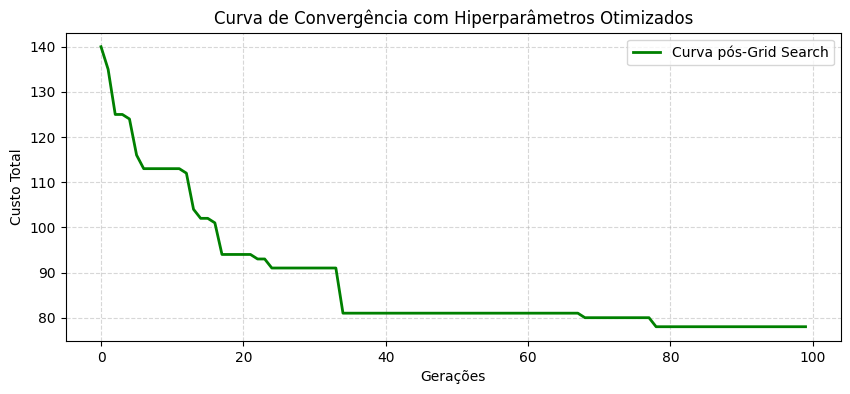

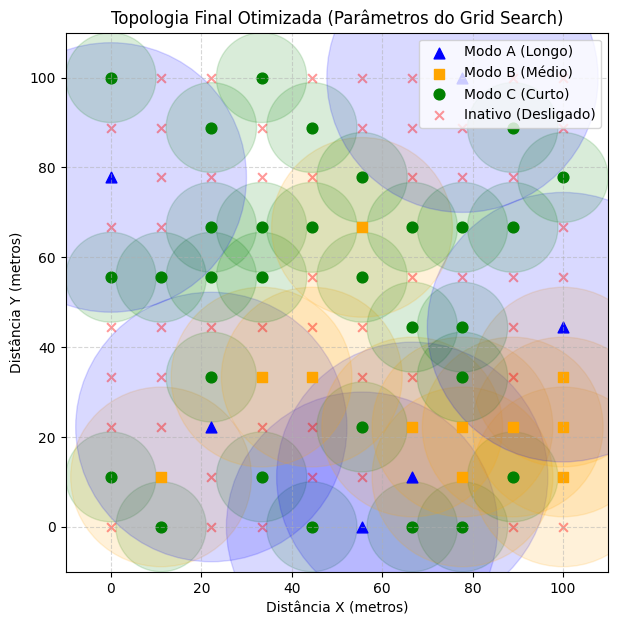


=== ANÁLISE DOS SENSORES FINAL OTIMIZADO PELO GRID SEARCH ===
• Inativos/Desligados (00): 53 sensores
• Modo A (Alcance Longo  01 - Potência: Máxima): 6 sensores
• Modo B (Alcance Médio  10 - Potência: Média): 11 sensores
• Modo C (Alcance Curto  11 - Potência: Fraca): 30 sensores
-> Total de nós ativos: 47 de 100
-> Custo Total Calculado: 76


In [12]:
print("\n=== EXECUTANDO A REDE DEFINITIVA COM OS PARÂMETROS DO GRID ===")

melhor_pop, melhor_cross, melhor_mut = melhor_combinacao

# 1. Geramos uma nova população inicial controlada com o tamanho ideal encontrado
populacao_grid = create_population(melhor_pop, CHROMOSOME_LENGTH)
ind_antes_grid = populacao_grid[0]

print(f"Configuração adotada: População={melhor_pop} | Crossover={melhor_cross} | Mutação={melhor_mut}")
print(f"Custo Inicial na Geração 0: {calculate_fitness(ind_antes_grid)}")

# 2. Executa a evolução com os parâmetros otimizados
# (Aumentamos as gerações para 100 para dar tempo de o algoritmo alcançar o ápice)
best_chromosome_grid, history_grid = run_genetic_algorithm_com_pop(populacao_grid) 

print(f"\nCusto Final Absoluto Otimizado pós-Grid: {calculate_fitness(best_chromosome_grid)}")

# 3. Gráfico de Convergência Otimizado
plt.figure(figsize=(10, 4))
plt.plot(history_grid, color='green', linewidth=2, label='Curva pós-Grid Search')
plt.title("Curva de Convergência com Hiperparâmetros Otimizados")
plt.xlabel("Gerações")
plt.ylabel("Custo Total")
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.show()

# 4. Mapa da Rede com a melhor combinação
plot_network_coverage(best_chromosome_grid, title="Topologia Final Otimizada (Parâmetros do Grid Search)")

# 5. Análise numérica final
analisar_topologia(best_chromosome_grid, momento="Final Otimizado pelo Grid Search")